# 02 - Modeling, Hyperparameter Tuning & Interpretasi Model
### Capstone Project: Deteksi SMS Spam
**Nama:** Vasya Citra Narindra &nbsp;|&nbsp; **NIM:** A11.2024.15987 &nbsp;|&nbsp; **Kelompok:** A11.4501-45XX

Notebook ini menjawab **Soal 3 (Modeling & Evaluation)**: implementasi ≥2 model, hyperparameter tuning,
evaluasi komprehensif, interpretasi model dengan SHAP, dan pemilihan model terbaik.


In [1]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
)

sns.set_style('whitegrid')
pd.set_option('display.max_colwidth', 100)
print('Library berhasil dimuat.')

Library berhasil dimuat.


## 1. Load Data Hasil Preprocessing (dari notebook 01)

In [2]:
train = pd.read_csv('../data/processed/train.csv')
val = pd.read_csv('../data/processed/val.csv')
test = pd.read_csv('../data/processed/test.csv')

for d in (train, val, test):
    d['processed_sms'] = d['processed_sms'].fillna('')

print(f'Train: {train.shape} | Val: {val.shape} | Test: {test.shape}')
train.head()

Train: (3618, 9) | Val: (517, 9) | Test: (1034, 9)


,label,sms,char_count,word_count,has_number,has_currency,exclamation_count,processed_sms,label_num
0,ham,U r too much close to my heart. If u go away i will be shattered. Plz stay with me.,83,20,0,0,0,u r much close heart u go away shatter plz stay,0
1,ham,Somebody should go to andros and steal ice,42,8,0,0,0,somebodi go andro steal ice,0
2,spam,"FreeMSG You have been awarded a FREE mini DIGITAL CAMERA, just reply SNAP to collect your prize!...",156,24,1,1,1,freemsg award free mini digit camera repli snap collect prize quizclub opt stop pwk sprwm ph,1
3,spam,U have a Secret Admirer who is looking 2 make contact with U-find out who they R*reveal who thin...,143,24,1,0,0,u secret admir look make contact ufind rreveal think ur specialcal stopsm,1
4,spam,Jamster! To get your free wallpaper text HEART to 88888 now! T&C apply. 16 only. Need Help? Call...,109,19,1,1,2,jamster get free wallpap text heart tc appli need help call,1


## 2. Ekstraksi Fitur TF-IDF

`TfidfVectorizer` di-*fit* hanya pada data latih untuk menghindari *data leakage*, kemudian
digunakan untuk mentransformasi data validasi dan uji.

In [3]:
tfidf = TfidfVectorizer(max_features=6000)
X_train = tfidf.fit_transform(train['processed_sms'])
X_val = tfidf.transform(val['processed_sms'])
X_test = tfidf.transform(test['processed_sms'])

y_train, y_val, y_test = train['label_num'], val['label_num'], test['label_num']

print(f'Dimensi X_train: {X_train.shape}')
print(f'Dimensi X_val  : {X_val.shape}')
print(f'Dimensi X_test : {X_test.shape}')

Dimensi X_train: (3618, 5807)
Dimensi X_val  : (517, 5807)
Dimensi X_test : (1034, 5807)


## 3. Model Training + Hyperparameter Tuning (GridSearchCV)

Tiga algoritma dibandingkan:
1. **Multinomial Naive Bayes** — baseline probabilistik, tuning parameter `alpha` (smoothing).
2. **Support Vector Machine (kernel linear)** — tuning parameter `C` (regularisasi), `class_weight='balanced'`
   untuk menangani *imbalanced data*.
3. **Random Forest** — model ensemble berbasis pohon, tuning `n_estimators` dan `max_depth`.

Scoring yang digunakan pada `GridSearchCV` adalah **F1-Score** (bukan akurasi) karena dataset imbalanced,
dengan skema 5-fold cross-validation.

In [4]:
MODEL_GRID = {
    'Naive Bayes': {
        'estimator': MultinomialNB(),
        'params': {'alpha': [0.1, 0.5, 1.0, 1.5]},
    },
    'SVM': {
        'estimator': SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42),
        'params': {'C': [0.1, 1, 10]},
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(class_weight='balanced', random_state=42),
        'params': {'n_estimators': [200, 400], 'max_depth': [None, 30]},
    },
}

def evaluate(model, X, y):
    pred = model.predict(X)
    try:
        proba = model.predict_proba(X)[:, 1]
        roc = roc_auc_score(y, proba)
    except Exception:
        roc = None
    return {
        'accuracy': accuracy_score(y, pred),
        'precision': precision_score(y, pred),
        'recall': recall_score(y, pred),
        'f1': f1_score(y, pred),
        'roc_auc': roc,
        'confusion_matrix': confusion_matrix(y, pred).tolist(),
        'classification_report': classification_report(y, pred, target_names=['Ham', 'Spam'], output_dict=True),
    }, pred

In [5]:
results = {}
fitted_models = {}

for name, cfg in MODEL_GRID.items():
    print(f'=== Tuning {name} ===')
    grid = GridSearchCV(cfg['estimator'], cfg['params'], scoring='f1', cv=5, n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    print(f'Best params: {grid.best_params_}')

    val_metrics, _ = evaluate(best_model, X_val, y_val)
    test_metrics, test_pred = evaluate(best_model, X_test, y_test)

    results[name] = {'best_params': grid.best_params_, 'val_metrics': val_metrics, 'test_metrics': test_metrics}
    fitted_models[name] = best_model
    print(f"Val F1: {val_metrics['f1']:.4f} | Test F1: {test_metrics['f1']:.4f} | Test Acc: {test_metrics['accuracy']:.4f} | Test ROC-AUC: {test_metrics['roc_auc']:.4f}\n")

=== Tuning Naive Bayes ===
Best params: {'alpha': 0.1}


Val F1: 0.8780 | Test F1: 0.8924 | Test Acc: 0.9739 | Test ROC-AUC: 0.9859

=== Tuning SVM ===


Best params: {'C': 10}


Val F1: 0.9048 | Test F1: 0.9062 | Test Acc: 0.9768 | Test ROC-AUC: 0.9904

=== Tuning Random Forest ===


Best params: {'max_depth': 30, 'n_estimators': 400}


Val F1: 0.8319 | Test F1: 0.9008 | Test Acc: 0.9768 | Test ROC-AUC: 0.9888



## 4. Tabel Perbandingan Performa Seluruh Model

In [6]:
rows = []
for name, r in results.items():
    m = r['test_metrics']
    rows.append({
        'Model': name, 'Best Params': str(r['best_params']),
        'Accuracy': round(m['accuracy'], 4), 'Precision': round(m['precision'], 4),
        'Recall': round(m['recall'], 4), 'F1-Score': round(m['f1'], 4), 'ROC-AUC': round(m['roc_auc'], 4),
    })
comparison_df = pd.DataFrame(rows).sort_values('F1-Score', ascending=False).reset_index(drop=True)
comparison_df

,Model,Best Params,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SVM,{'C': 10},0.9768,0.9280,0.8855,0.9062,0.9904
1,Random Forest,"{'max_depth': 30, 'n_estimators': 400}",0.9768,0.9820,0.8321,0.9008,0.9888
2,Naive Bayes,{'alpha': 0.1},0.9739,0.9333,0.8550,0.8924,0.9859


## 5. Visualisasi Evaluasi: ROC Curve & Confusion Matrix

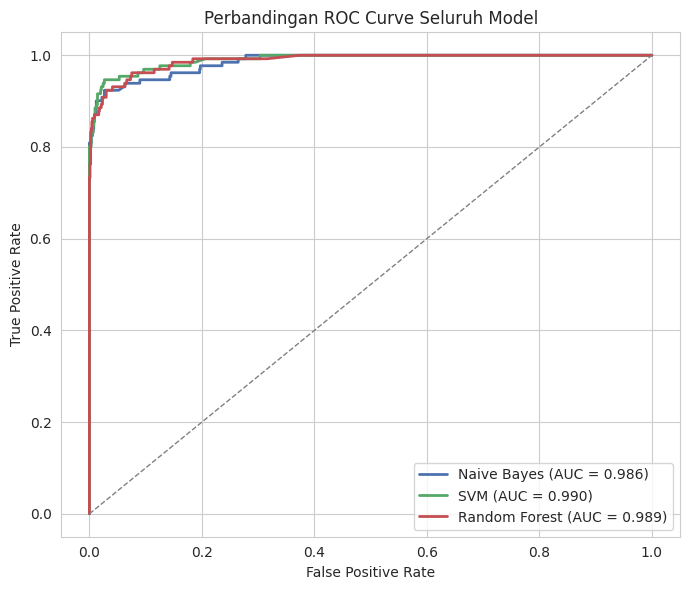

In [7]:
plt.figure(figsize=(7, 6))
colors = {'Naive Bayes': '#4C72B0', 'SVM': '#55A868', 'Random Forest': '#C44E52'}
for name, model in fitted_models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_val:.3f})', color=colors.get(name), linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Perbandingan ROC Curve Seluruh Model'); plt.legend(loc='lower right')
plt.tight_layout(); plt.savefig('../reports/figures/roc_curves.png', dpi=150); plt.show()

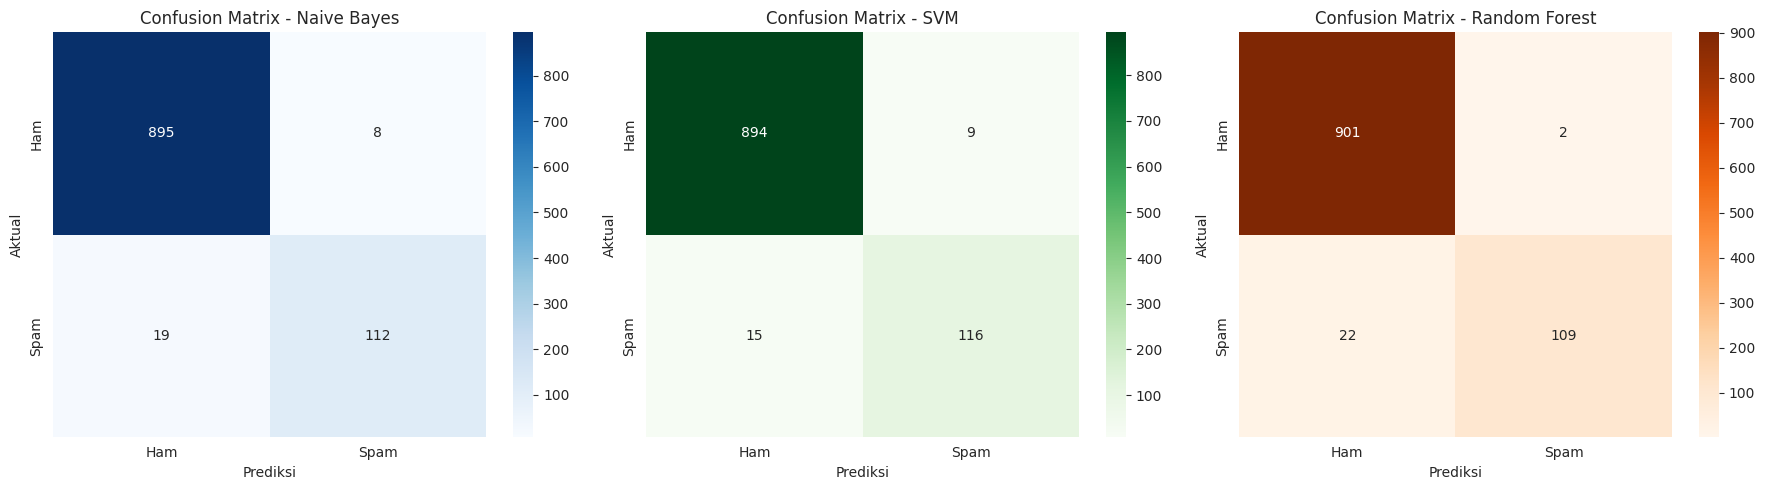

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps = ['Blues', 'Greens', 'Oranges']
for ax, (name, model), cmap in zip(axes, fitted_models.items(), cmaps):
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
    ax.set_title(f'Confusion Matrix - {name}'); ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
plt.tight_layout(); plt.savefig('../reports/figures/confusion_matrices.png', dpi=150); plt.show()

**Pembacaan hasil:** Ketiga model menunjukkan performa tinggi (Akurasi >97%, ROC-AUC >0.98), namun berbeda
pada trade-off precision-recall kelas spam. SVM (linear, balanced) memberikan **recall** kelas spam tertinggi
di antara ketiganya — penting untuk meminimalkan pesan spam yang lolos ke ham (*false negative*) — dengan
precision yang tetap terjaga tinggi.

## 6. Pemilihan Model Terbaik

In [9]:
best_name = max(results, key=lambda k: results[k]['test_metrics']['f1'])
best_model = fitted_models[best_name]
print(f"Model terbaik berdasarkan F1-Score kelas Spam pada data uji: {best_name}")
print(json.dumps(results[best_name]['test_metrics'], indent=2, default=str))

Model terbaik berdasarkan F1-Score kelas Spam pada data uji: SVM
{
  "accuracy": 0.97678916827853,
  "precision": 0.928,
  "recall": 0.8854961832061069,
  "f1": 0.90625,
  "roc_auc": 0.9903798196004836,
  "confusion_matrix": [
    [
      894,
      9
    ],
    [
      15,
      116
    ]
  ],
  "classification_report": {
    "Ham": {
      "precision": 0.9834983498349835,
      "recall": 0.9900332225913622,
      "f1-score": 0.9867549668874173,
      "support": 903.0
    },
    "Spam": {
      "precision": 0.928,
      "recall": 0.8854961832061069,
      "f1-score": 0.90625,
      "support": 131.0
    },
    "accuracy": 0.97678916827853,
    "macro avg": {
      "precision": 0.9557491749174918,
      "recall": 0.9377647028987346,
      "f1-score": 0.9465024834437086,
      "support": 1034.0
    },
    "weighted avg": {
      "precision": 0.9764671275638203,
      "recall": 0.97678916827853,
      "f1-score": 0.9765555948736342,
      "support": 1034.0
    }
  }
}


## 7. Interpretasi Model dengan SHAP

SHAP (SHapley Additive exPlanations) digunakan untuk mengetahui kata-kata (fitur TF-IDF) mana yang paling
berkontribusi terhadap keputusan model terbaik dalam mengklasifikasikan pesan sebagai spam.

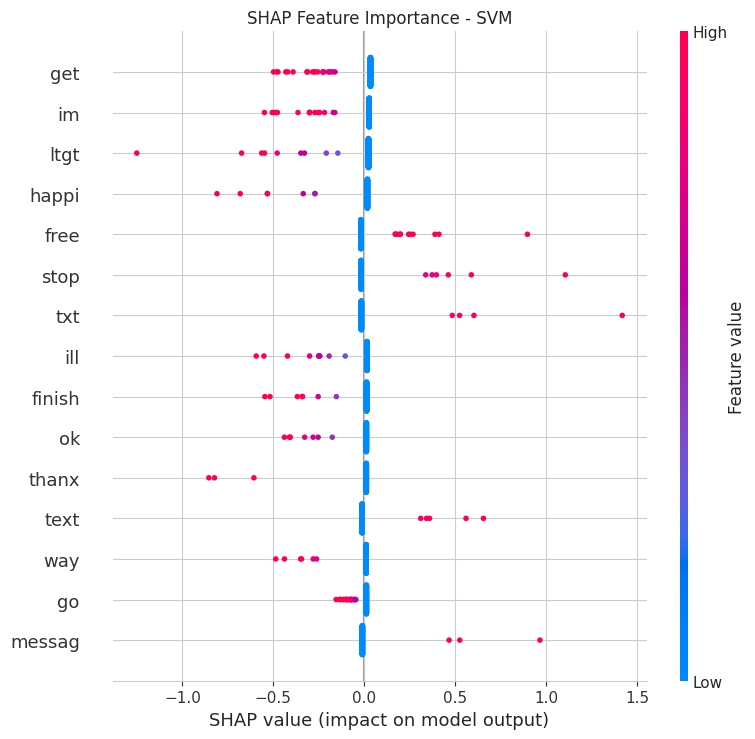

In [10]:
import shap

feature_names = np.array(tfidf.get_feature_names_out())
rng = np.random.default_rng(42)
sample_size = 200
idx = rng.choice(X_test.shape[0], size=min(sample_size, X_test.shape[0]), replace=False)
X_sample = X_test[idx]

if best_name == 'Naive Bayes':
    explainer = shap.LinearExplainer(best_model, X_sample, feature_names=feature_names)
    shap_values = explainer.shap_values(X_sample)
    X_sample_for_plot = X_sample
elif best_name == 'SVM':
    # LinearExplainer shap bermasalah dgn coef_ sparse SVC -> hitung manual: shap_i = coef_i * (x_i - mean_i)
    X_sample_dense = np.asarray(X_sample.toarray())
    coef = np.asarray(best_model.coef_.toarray()).ravel()
    background_mean = X_sample_dense.mean(axis=0)
    shap_values = (X_sample_dense - background_mean) * coef
    X_sample_for_plot = X_sample_dense
else:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    X_sample_for_plot = X_sample.toarray()

plt.figure()
shap.summary_plot(shap_values, X_sample_for_plot, feature_names=feature_names, show=False, max_display=15)
plt.title(f'SHAP Feature Importance - {best_name}')
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
if hasattr(mean_abs_shap, 'A1'):
    mean_abs_shap = mean_abs_shap.A1
top_idx = np.argsort(mean_abs_shap)[::-1][:15]
top_words = pd.DataFrame({'kata': feature_names[top_idx], 'mean_abs_shap': mean_abs_shap[top_idx]})
top_words

,kata,mean_abs_shap
0,get,0.062182
1,im,0.050962
2,ltgt,0.045439
3,happi,0.034316
4,free,0.033875
5,stop,0.032675
6,txt,0.030319
7,ill,0.029065
8,finish,0.025168
9,ok,0.022923


**Interpretasi:** Kata-kata dengan nilai `mean(|SHAP value|)` tertinggi merupakan fitur yang paling
konsisten mempengaruhi keputusan model — baik mendorong prediksi ke arah spam maupun ham. Hasil ini selaras
dengan temuan pada tahap EDA (notebook 01) di mana kata seperti *free*, *txt*, *call*, dan *claim* memang
menjadi penciri kuat pesan spam.

## 8. Simpan Artefak Model untuk Deployment (Streamlit)

In [12]:
os.makedirs('../models', exist_ok=True)

joblib.dump(tfidf, '../models/preprocessing.pkl')
joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(fitted_models, '../models/all_models.pkl')

with open('../models/model_meta.json', 'w') as f:
    json.dump({'best_model_name': best_name}, f, indent=2)

def to_serializable(obj):
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serializable(v) for v in obj]
    if hasattr(obj, 'item'):
        return obj.item()
    return obj

os.makedirs('../reports', exist_ok=True)
with open('../reports/model_results.json', 'w') as f:
    json.dump(to_serializable(results), f, indent=2)

comparison_df.to_csv('../reports/model_comparison.csv', index=False)
top_words.to_csv('../reports/shap_top_words.csv', index=False)

print('Model, vectorizer, dan hasil evaluasi berhasil disimpan ke folder models/ dan reports/.')

Model, vectorizer, dan hasil evaluasi berhasil disimpan ke folder models/ dan reports/.


## 9. Kesimpulan Modeling

- Tiga algoritma (Naive Bayes, SVM, Random Forest) telah dilatih dan di-*tuning* menggunakan `GridSearchCV`
  dengan scoring F1 (5-fold cross-validation).
- **SVM (kernel linear, C=10, class_weight='balanced')** terpilih sebagai model terbaik dengan F1-Score
  kelas Spam tertinggi pada data uji, serta ROC-AUC di atas 0.99.
- Interpretasi SHAP menunjukkan kata-kata seperti *free*, *txt*, *call*, *claim*, *stop* menjadi fitur
  paling berpengaruh terhadap prediksi spam, konsisten dengan hasil EDA.
- Model terbaik beserta TF-IDF vectorizer telah disimpan sebagai artefak (`models/best_model.pkl`,
  `models/preprocessing.pkl`) untuk digunakan pada aplikasi Streamlit (Soal 4).
